In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

In [2]:
data = load_breast_cancer()
X, y = data.data, 1 - data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=1)

In [4]:
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000))

In [5]:
param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

In [7]:
train_scores, test_scores = validation_curve(
    estimator=pipe,
    X=X_train,
    y=y_train,
    param_name='logisticregression__C',
    param_range=param_range,
    cv=10,
    n_jobs=-1
)

In [8]:
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

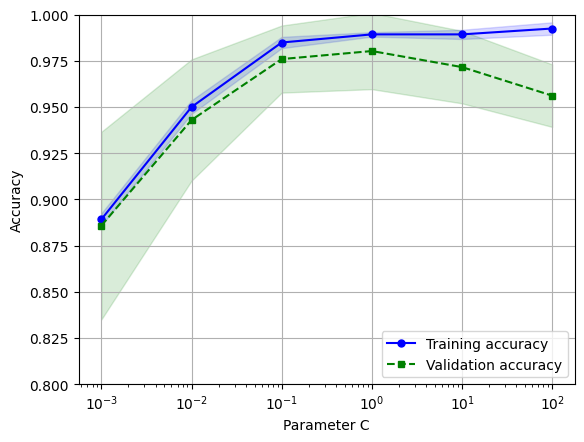

In [10]:
plt.plot(param_range, train_mean, color='blue', marker='o',
         markersize=5, label='Training accuracy')
plt.fill_between(param_range, train_mean + train_std,
                 train_mean - train_std, alpha=0.15, color='blue')

plt.plot(param_range, test_mean, color='green', linestyle='--',
         marker='s', markersize=5, label='Validation accuracy')
plt.fill_between(param_range, test_mean + test_std,
                 test_mean - test_std, alpha=0.15, color='green')

plt.grid()
plt.xscale('log')
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.0])
plt.show()

In [11]:
print("     C   train   valid    gap")
for c, tr, va in zip(param_range, train_mean, test_mean):
    print(f"{c:6}   {tr:.3f}   {va:.3f}   {tr-va:+.3f}")

     C   train   valid    gap
 0.001   0.889   0.886   +0.003
  0.01   0.950   0.943   +0.007
   0.1   0.985   0.976   +0.009
   1.0   0.989   0.980   +0.009
  10.0   0.989   0.972   +0.018
 100.0   0.992   0.956   +0.036
